In [1]:
import cv2
import numpy as np
import pandas as pd
import math
import os
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import PIL.Image

In [2]:
input_video_path = "two_channel.mp4"
output_csv_path = "double_results.csv"

In [3]:
# 1. Initialize Video Capture
cap = cv2.VideoCapture(input_video_path)
if not cap.isOpened():
    print(f"Error: Could not open video {input_video_path}")
    exit()
    
# aircraft parameters
rod_length_mm = 10.33  # mm

# List to store data for each frame
data_log = []

frame_count = 0
fps = cap.get(cv2.CAP_PROP_FPS) if cap.get(cv2.CAP_PROP_FPS) > 0 else 240
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

display_every_n_frames = 10
cx = frame_width // 2
cy = frame_height // 2
window_size = 220

# Centered square crop window with bounds clamped to the frame
half_window = window_size // 2
x1 = cx - half_window
y1 = cy - half_window - 80
x2 = cx + half_window
y2 = cy + half_window - 80

# ROI (bottom-right of cropped frame)
roi_size = 50
prev_brightness = None
change_threshold = 10
brightness_frames = []



In [4]:
import cv2
import numpy as np
import math
import pandas as pd
import PIL.Image
from IPython.display import display, clear_output

# Minor-axis tilt reference
l0 = None

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    cropped = frame[y1:y2, x1:x2]
    
    # 1. Grayscale and basic threshold
    gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 90, 255, cv2.THRESH_BINARY)
    
    # 2. ROI Brightness detection
    h, w = binary.shape[:2]
    rx1, ry1 = max(w - roi_size, 0), max(h - roi_size - 20, 0)
    current_brightness = cv2.mean(binary[ry1:h, rx1:w])[0]

    if prev_brightness is not None and abs(prev_brightness - current_brightness) > change_threshold:
        print(f"Brightness drop detected at frame {frame_count}: {current_brightness:.2f}")
        brightness_frames.append(frame_count)
    prev_brightness = current_brightness

    # 3. Disconnect thin strings/sticks using Morphological Opening
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (12,12))
    clean_mask = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # 4. Find contours and strictly keep only the largest one
    contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    frame_data = {
        "frame": frame_count, "timestamp_sec": frame_count / fps, "detected": False,
        "line_point_x": None, "line_point_y": None, "line_dir_x": None, "line_dir_y": None,
        "line_angle_deg_major": None, "line_angle_deg_minor": None, "longest_width_px": None,
        "contour_area_px": None, "final_combined_angle_deg": None, "minor_len_px": None,
        "top_ellipse_major_len_px": None, "top_ellipse_minor_len_px": None
    }

    overlay = frame.copy()  # Draw on full frame instead of binary
    
    if contours:
        best_cnt = max(contours, key=cv2.contourArea)
        
        # Only process if the blob is substantial
        if cv2.contourArea(best_cnt) > 200:
            contour_fill_mask = np.zeros_like(gray)
            cv2.drawContours(contour_fill_mask, [best_cnt], -1, 255, cv2.FILLED)
            
            # Use filled outer contour area so inner holes do not shrink A at large tilt
            contour_area = float(np.count_nonzero(contour_fill_mask))
            frame_data["contour_area_px"] = round(contour_area, 2)

            y_idx, x_idx = np.nonzero(contour_fill_mask)
            pts = np.column_stack((x_idx, y_idx)).astype(np.float32)
            
            if len(pts) >= 10:
                # 5. PCA Analysis
                mean, eigenvectors, eigenvalues = cv2.PCACompute2(pts, mean=None)
                cx_local, cy_local = mean[0, 0], mean[0, 1]
                
                # Primary eigenvector (major axis) directions
                vx, vy = eigenvectors[0, 0], eigenvectors[0, 1]
                
                # Calculate Major Angle (2D Roll/Yaw)
                angle_rad_major = math.atan2(vy, vx)
                angle_deg_major = math.degrees(angle_rad_major)
                
                # Project pixels onto eigenvectors to calculate EXACT tight bounds
                centered = pts - mean[0]
                proj_major = np.dot(centered, eigenvectors[0])
                proj_minor = np.dot(centered, eigenvectors[1])
                
                major_len = float(proj_major.max() - proj_major.min())

                # Use the smallest-side minor length (per your request)
                minor_len = math.fabs(2 * float(proj_minor.min()))

                # Store minor length in the per-frame data (CSV will keep this)
                frame_data["minor_len_px"] = round(float(minor_len), 2)

                # Normalize major angle for readable output
                if angle_deg_major > 90: angle_deg_major -= 180
                elif angle_deg_major < -90: angle_deg_major += 180

                # Convert local crop coordinates to full-frame coordinates
                cx_full = float(cx_local + x1)
                cy_full = float(cy_local + y1)

                frame_data.update({
                    "detected": True, "line_point_x": round(cx_full, 2), "line_point_y": round(cy_full, 2),
                    "line_dir_x": round(float(vx), 4), "line_dir_y": round(float(vy), 4),
                    "line_angle_deg_major": round(angle_deg_major, 2),
                    "longest_width_px": round(major_len, 2)
                })

                # Print to console (keep informative prints)
                print(f"Frame {frame_count} | Major (2D): {angle_deg_major:.2f}° | Minor Length: {minor_len:.2f} px")

                # --- Visualizations on full frame ---
                best_cnt_full = best_cnt.copy()
                best_cnt_full[:, :, 0] += x1
                best_cnt_full[:, :, 1] += y1
                cv2.drawContours(overlay, [best_cnt_full], -1, (0, 255, 0), 1)
                
                # Fit a top contour ellipse from top-band points and use its axes for angle computation
                cnt_pts_local = best_cnt[:, 0, :].astype(np.float32)
                rx = float(max(0.0, major_len / 2.0))
                ry_fit = 0.0
                cx_ell_local, cy_ell_local = cx_local, cy_local
                angle_ell_deg = angle_deg_major
                top_fit_major_len = None
                top_fit_minor_len = None
                top_pts = np.empty((0, 2), dtype=np.float32)
                top_band_y_local = None
                if len(cnt_pts_local) >= 5 and rx > 1.0:
                    y_min_cnt = float(np.min(cnt_pts_local[:, 1]))
                    y_max_cnt = float(np.max(cnt_pts_local[:, 1]))
                    top_band_h = max(2.0, 0.1 * (y_max_cnt - y_min_cnt))
                    top_band_y_local = y_min_cnt + top_band_h
                    top_pts = cnt_pts_local[cnt_pts_local[:, 1] <= top_band_y_local]
                    if len(top_pts) >= 5:
                        # Ensure theta is a float
                        theta = math.radians(angle_deg_major)
                        dx = top_pts[:, 0] - cx_local
                        dy = top_pts[:, 1] - cy_local
                        x_rot = dx * math.cos(theta) + dy * math.sin(theta)
                        y_rot = -dx * math.sin(theta) + dy * math.cos(theta)
                        inside = np.clip(1.0 - (x_rot * x_rot) / (rx * rx), 0.0, 1.0)
                        valid = inside > 1e-6
                        if np.count_nonzero(valid) >= 3:
                            s = np.sqrt(inside[valid])
                            A = np.column_stack((np.ones_like(s), -s))
                            b = y_rot[valid]
                            # Solve y_rot ~= yc_shift - ry*s with yc constrained to the minor-axis line (x_shift = 0)
                            sol, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
                            yc_shift = float(sol[0])
                            ry_fit = max(0.0, float(sol[1]))
                            cx_ell_local = cx_local - yc_shift * math.sin(theta)
                            cy_ell_local = cy_local + yc_shift * math.cos(theta)
                            # Set top-ellipse axis lengths (full axis lengths, not radii)
                            top_fit_major_len = max(0.0, 2.0 * rx)
                            top_fit_minor_len = max(0.0, 2.0 * ry_fit)
                # Visualize the top-band segment used for fitting
                if top_band_y_local is not None:
                    y_band_full = int(round(top_band_y_local + y1))
                    cv2.line(overlay, (x1, y_band_full), (x2, y_band_full), (255, 128, 0), 1)
                if len(top_pts) > 0:
                    top_pts_full = top_pts.copy()
                    top_pts_full[:, 0] += x1
                    top_pts_full[:, 1] += y1
                    for p in top_pts_full:
                        cv2.circle(overlay, (int(p[0]), int(p[1])), 1, (255, 0, 255), -1)
                if top_fit_major_len is not None and top_fit_minor_len is not None:
                    frame_data["top_ellipse_major_len_px"] = round(top_fit_major_len, 2)
                    frame_data["top_ellipse_minor_len_px"] = round(top_fit_minor_len, 2)
                    # Compute minor-axis tilt from foreshortening ratio: angle = acos(min/major)
                    ratio = 1.0
                    if top_fit_major_len > 0:
                        ratio = top_fit_minor_len / top_fit_major_len
                    ratio = min(max(ratio, 0.0), 1.0)
                    angle_rad_minor = math.acos(ratio)
                    angle_deg_minor = math.degrees(angle_rad_minor)
                    if angle_deg_minor > 90:
                        angle_deg_minor -= 180
                    elif angle_deg_minor < -90:
                        angle_deg_minor += 180
                    # Combine azimuth (major) and radial tilt into final axis angles

                    
                    phi = math.radians(angle_deg_major)
                    beta = angle_rad_minor
                    u_x = math.cos(beta) * math.cos(phi)
                    u_y = math.cos(beta) * math.sin(phi)
                    u_z = math.sin(beta)
                    # angle between axis and image vertical (0,1,0)
                    # angle_to_vertical = math.degrees(math.acos(max(min(u_y, 1.0), -1.0)))
                    
                    angle_to_plane = math.degrees(math.acos(max(min(u_z, 1.0), -1.0)))


                    frame_data["final_combined_angle_deg"] = round(angle_to_plane, 2)
                    
                    
                rx_i = int(max(0, round(rx)))
                ry_i = int(max(0, round(ry_fit)))
                cx_ell_full = cx_ell_local + x1
                cy_ell_full = cy_ell_local + y1
                cv2.ellipse(overlay, (int(cx_ell_full), int(cy_ell_full)), (rx_i, ry_i), angle_ell_deg, 180, 360, (0, 255, 255), 2)

                # Draw Central Axis Line
                L = major_len / 2
                pt1 = (int(cx_full - vx * L), int(cy_full - vy * L))
                pt2 = (int(cx_full + vx * L), int(cy_full + vy * L))
                cv2.line(overlay, pt1, pt2, (255, 0, 0), 2)
                cv2.circle(overlay, (int(cx_full), int(cy_full)), 4, (0, 0, 255), -1)
                
                # Display Major angle and Minor length on the video frame (keep putText lines)
                cv2.putText(overlay, f"Major Angle: {angle_deg_major:.2f} deg", (10, 25), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
                cv2.putText(overlay, f"Final combined angle: {angle_to_plane:.2f} deg", (10, 50), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 255), 2)

    # Overlay the binary mask onto the full frame
    main_mask_bgr = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
    if (y2 > y1) and (x2 > x1) and overlay[y1:y2, x1:x2].shape[:2] == main_mask_bgr.shape[:2]:
        overlay[y1:y2, x1:x2] = cv2.addWeighted(overlay[y1:y2, x1:x2], 0.5, main_mask_bgr, 0.5, 0)
    
    # Draw crop rectangle on full frame
    cv2.rectangle(overlay, (x1, y1), (x2, y2), (255, 255, 0), 1)
    
    # Draw ROI rectangle on full frame
    roi_x1 = x1 + max(w - roi_size, 0)
    roi_y1 = y1 + max(h - roi_size - 20, 0)
    roi_x2 = x1 + w
    roi_y2 = y1 + h
    cv2.rectangle(overlay, (roi_x1, roi_y1), (roi_x2, roi_y2), (255, 0, 255), 1)
    
    data_log.append(frame_data)

    if frame_count % 100 == 0:
        print(f"Processed {frame_count} frames...")

    # Visualization refresh
    if frame_count % display_every_n_frames == 0:
        img = PIL.Image.fromarray(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        clear_output(wait=True)
        display(img)

# Clean up and save intermediate results
cap.release()
df = pd.DataFrame(data_log)
df.to_csv(output_csv_path, index=False)
print(f"\nIntermediate results saved to: {output_csv_path}")

KeyboardInterrupt: 

Segment 0: Frames 579 to 799, Mean Angle: 0.00, Std: 0.00
Segment 1: Frames 839 to 978, Mean Angle: 0.00, Std: 0.00
Segment 2: Frames 1018 to 1156, Mean Angle: 0.00, Std: 0.00
Segment 3: Frames 1196 to 1335, Mean Angle: 0.00, Std: 0.00
Segment 4: Frames 1375 to 1513, Mean Angle: 0.00, Std: 0.00
Segment 5: Frames 1553 to 1694, Mean Angle: 0.00, Std: 0.00
Segment 6: Frames 1734 to 1873, Mean Angle: 0.00, Std: 0.00
Segment 7: Frames 1913 to 2052, Mean Angle: 0.00, Std: 0.00
Segment 8: Frames 2092 to 2232, Mean Angle: 0.00, Std: 0.00
Segment 9: Frames 2272 to 2411, Mean Angle: 0.00, Std: 0.00


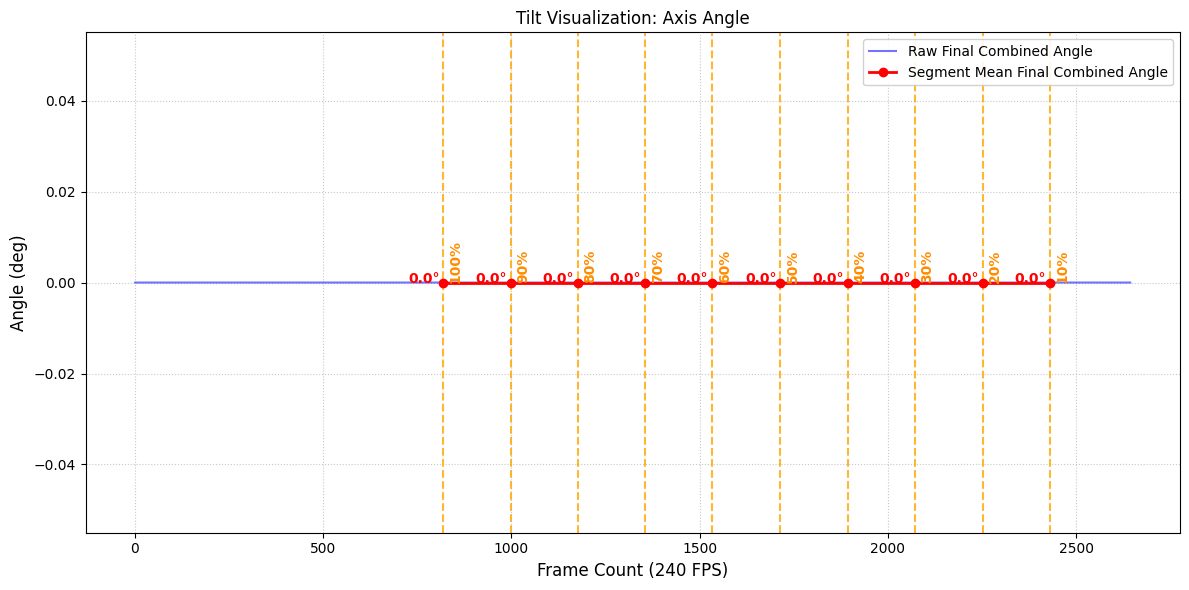

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load and filter detections
df = pd.read_csv(output_csv_path)
df = df[df['detected']].copy()

# Plot the final combined angle (azimuthal major-axis + radial area-based tilt)
angle_col = 'final_combined_angle_deg' if 'final_combined_angle_deg' in df.columns else 'true_floor_angle_deg'

# Compute segment means robustly based on actual frame values
mean_segment_angles = []
segment_std_angles = []
segment_buffer = 20

for i, time in enumerate(brightness_frames):
    seg_start = brightness_frames[i-1] + segment_buffer if i > 0 else brightness_frames[0] - 240
    seg_end = time - segment_buffer

    seg = df[(df['frame'] >= seg_start) & (df['frame'] <= seg_end)][angle_col]
    mean_val = seg.mean()
    std_val = seg.std()
    mean_segment_angles.append(mean_val)
    segment_std_angles.append(std_val)
    print(f"Segment {i}: Frames {seg_start} to {seg_end}, Mean Angle: {mean_val:.2f}, Std: {std_val:.2f}")

plt.figure(figsize=(12, 6))
plt.plot(df['frame'], df[angle_col], 'b-', alpha=0.55, label='Raw Final Combined Angle')

y_min, y_max = df[angle_col].min(), df[angle_col].max()
y_range = y_max - y_min

for i, bt in enumerate(brightness_frames):
    plt.axvline(bt, color='orange', linestyle='--', alpha=0.8)
    percentage_str = f'{100 - i*10}%'
    plt.text(bt + 15, y_min + y_range * 0.05, percentage_str,
             color='darkorange', rotation=90, va='bottom', ha='left',
             fontweight='bold', fontsize=10)

plt.plot(brightness_frames, mean_segment_angles, 'ro-', drawstyle='steps-pre',
         linewidth=2, markersize=6, label='Segment Mean Final Combined Angle')

# Error bars from per-segment variance (std dev)
# plt.errorbar(brightness_frames, mean_segment_angles, yerr=segment_std_angles, fmt='none',
#              ecolor='black', elinewidth=1.2, capsize=3, alpha=0.9,
#              label='Segment Std Dev')

for bt, mean_angle in zip(brightness_frames, mean_segment_angles):
    if pd.notna(mean_angle):
        plt.text(bt - 10, mean_angle + (y_range * 0.02), f"{mean_angle:.1f}°",
                 color='red', fontweight='bold', fontsize=10, ha='right')

plt.title('Tilt Visualization: Axis Angle')
plt.xlabel('Frame Count (240 FPS)', fontsize=12)
plt.ylabel('Angle (deg)', fontsize=12)
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()
